In [1]:
import learntools

In [4]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.feature_engineering_new.ex2 import *

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

In [5]:
# plt.style.use("seaborn-whitegrid")
sns.set_style("whitegrid")

df = pd.read_csv("../datasets/autos.csv")
df.head()

,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          193 non-null    int64  
 1   make               193 non-null    object 
 2   fuel_type          193 non-null    object 
 3   aspiration         193 non-null    object 
 4   num_of_doors       193 non-null    int64  
 5   body_style         193 non-null    object 
 6   drive_wheels       193 non-null    object 
 7   engine_location    193 non-null    object 
 8   wheel_base         193 non-null    float64
 9   length             193 non-null    float64
 10  width              193 non-null    float64
 11  height             193 non-null    float64
 12  curb_weight        193 non-null    int64  
 13  engine_type        193 non-null    object 
 14  num_of_cylinders   193 non-null    int64  
 15  engine_size        193 non-null    int64  
 16  fuel_system        193 non

In [7]:
X = df.copy()
y = X.pop("price")

In [8]:
# label encoding for categorical variables
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# discrete features
discrete_features = X.dtypes == int

In [9]:
def make_mi_scores(X, y, discrete_features):
    scores = mutual_info_regression(X, y, discrete_features='auto', n_neighbors=3, copy=True, random_state=None)
    scores = pd.Series(scores, name="MI Scores", index=X.columns)
    scores = scores.sort_values(ascending=False)
    return scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores

curb_weight          0.910991
engine_size          0.898943
horsepower           0.895050
highway_mpg          0.894208
city_mpg             0.779184
width                0.680790
length               0.609812
wheel_base           0.578220
bore                 0.485172
fuel_system          0.473487
stroke               0.381678
height               0.360169
drive_wheels         0.332448
num_of_cylinders     0.330548
make                 0.234693
symboling            0.232524
peak_rpm             0.215769
engine_type          0.149734
compression_ratio    0.101619
aspiration           0.087755
body_style           0.048640
fuel_type            0.047279
num_of_doors         0.012705
engine_location      0.000000
Name: MI Scores, dtype: float64

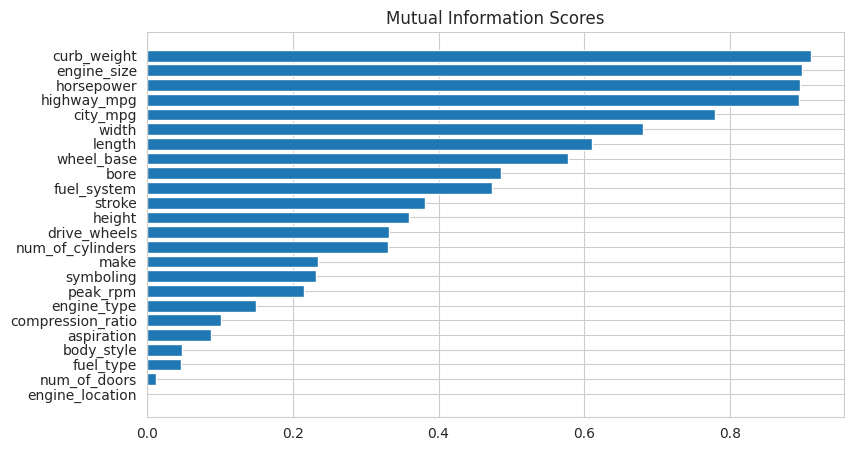

In [10]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plt.figure(dpi=100, figsize=(9,5))
plot_mi_scores(scores=mi_scores)

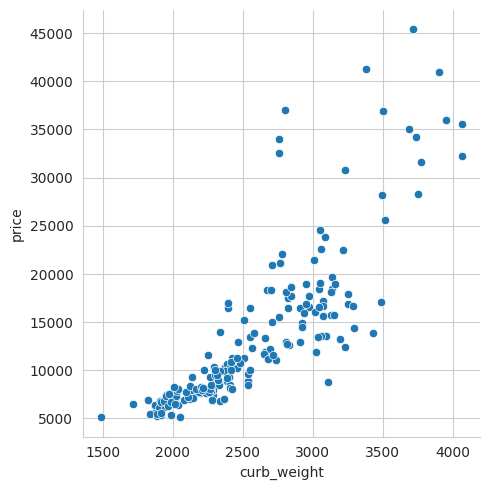

In [11]:
sns.relplot(x="curb_weight", y="price", data=df)

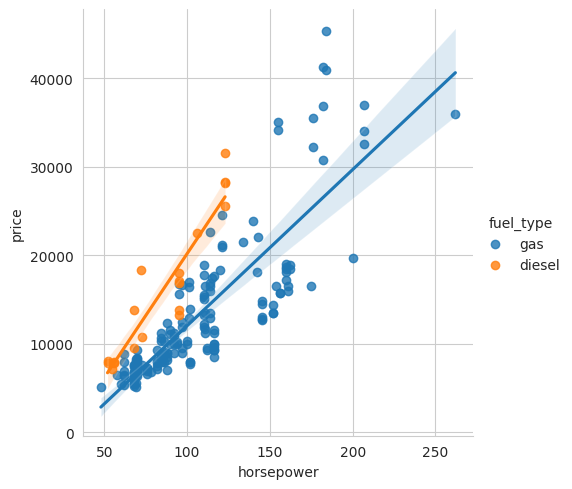

In [12]:
sns.lmplot(x="horsepower", y="price", hue="fuel_type", data=df)

In [13]:
# Set Matplotlib defaults
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


# Load data
df = pd.read_csv("../datasets/ames.csv")


# Utility functions from Tutorial
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

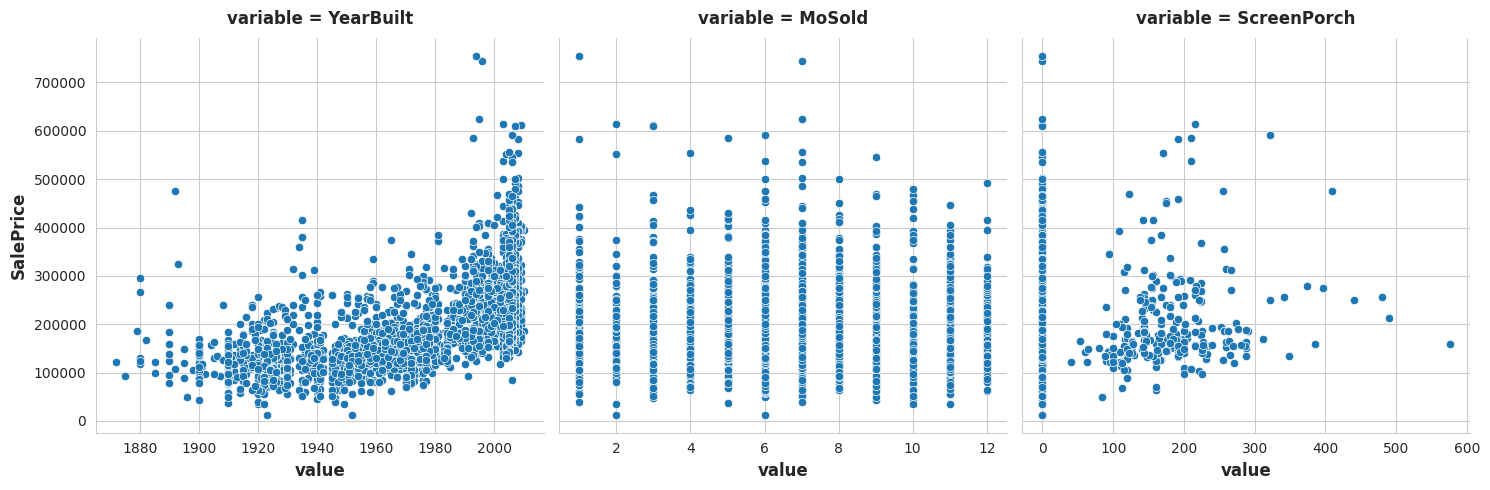

In [14]:
features = ["YearBuilt", "MoSold", "ScreenPorch"]
sns.relplot(
    x="value", y="SalePrice", col="variable", data=df.melt(id_vars="SalePrice", value_vars=features), facet_kws=dict(sharex=False),
);

In [15]:
X = df.copy()
y = X["SalePrice"]

mutual_info_scores = make_mi_scores(X, y)
mutual_info_scores

SalePrice           5.994127
OverallQual         0.581262
Neighborhood        0.569813
GrLivArea           0.496909
YearBuilt           0.437939
                      ...   
Utilities           0.000291
Threeseasonporch    0.000000
LandSlope           0.000000
MoSold              0.000000
BsmtFinSF2          0.000000
Name: MI Scores, Length: 79, dtype: float64

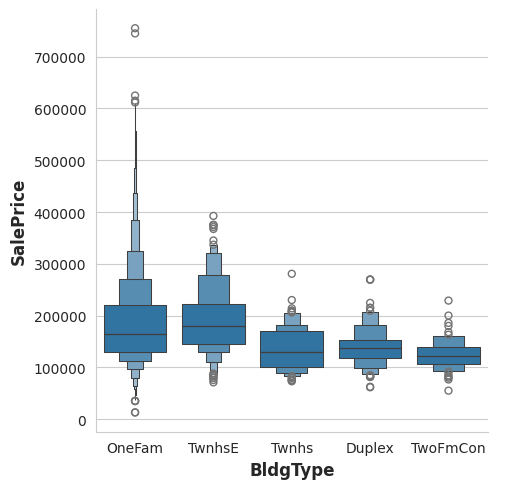

In [16]:
sns.catplot(x="BldgType", y="SalePrice", data=df, kind="boxen");

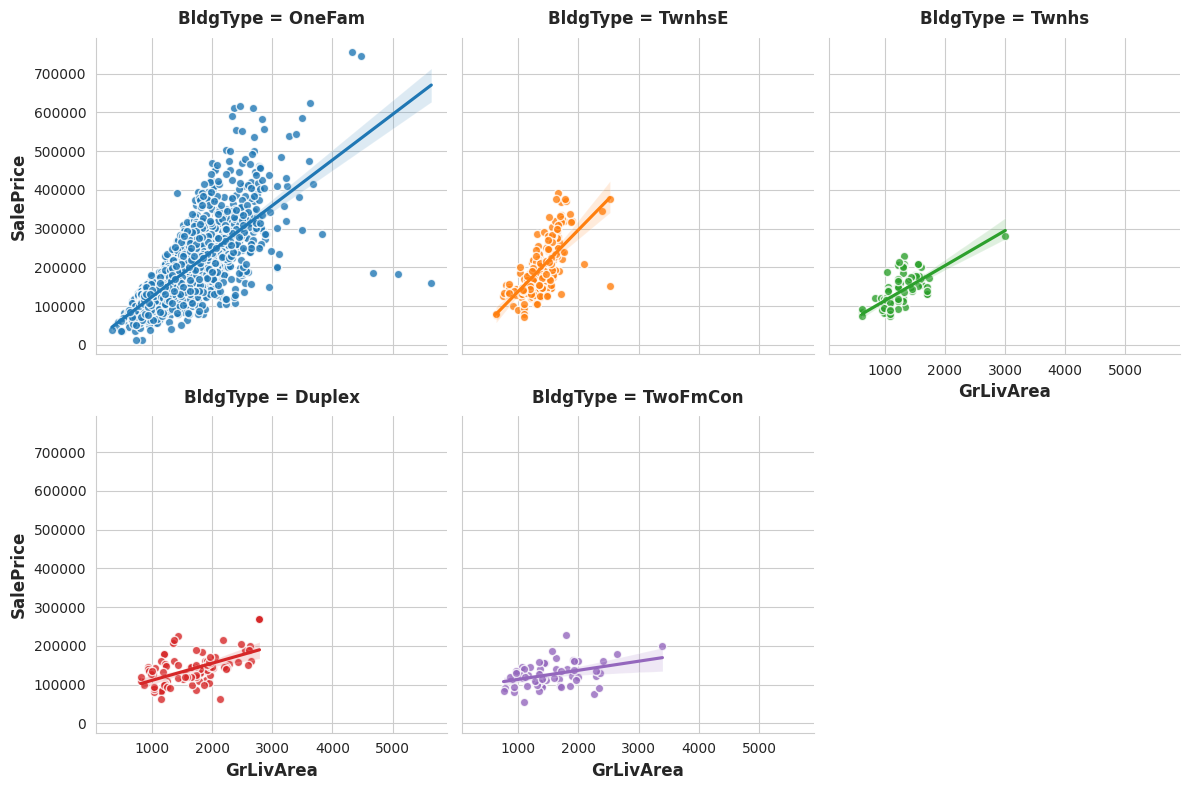

In [17]:
feature = "GrLivArea"

sns.lmplot(
    x=feature, y="SalePrice", hue="BldgType", col="BldgType",
    data=df, scatter_kws={"edgecolor": 'w'}, col_wrap=3, height=4,
);